In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_excel("Online Retail.xlsx")

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# Remove rows without CustomerID
data = data.dropna(subset=['CustomerID'])

# Remove cancelled invoices 
data = data[~data['InvoiceNo'].astype(str).str.startswith('C')]

# Convert InvoiceDate to datetime
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

# Create Revenue column
data['Revenue'] = data['Quantity'] * data['UnitPrice']

print("Cleaned shape:", data.shape)

Cleaned shape: (397924, 9)


In [5]:
# Set reference date (1 day after last purchase)
reference_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'Revenue': 'sum'                                            # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [6]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

# Convert to integers
rfm[['R_Score','F_Score','M_Score']] = rfm[['R_Score','F_Score','M_Score']].astype(int)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12346.0,326,1,77183.60,1,1,4
12347.0,2,7,4310.00,4,4,4
12348.0,75,4,1797.24,2,3,4
12349.0,19,1,1757.55,3,1,4
12350.0,310,1,334.40,1,1,2


In [7]:
rfm['RFM_Score'] = (rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str))

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,114
12347.0,2,7,4310.00,4,4,4,444
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,3,1,4,314
12350.0,310,1,334.40,1,1,2,112


In [8]:
def segment_customer(row):
    if row['RFM_Score'] == '444':
        return 'Champions'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return 'Loyal Customers'
    elif row['R_Score'] >= 3:
        return 'Potential Loyalists'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,Lost Customers
12347.0,2,7,4310.00,4,4,4,444,Champions
12348.0,75,4,1797.24,2,3,4,234,At Risk
12349.0,19,1,1757.55,3,1,4,314,Potential Loyalists
12350.0,310,1,334.40,1,1,2,112,Lost Customers


In [9]:
segment_counts = rfm['Segment'].value_counts()
print(segment_counts)

Segment
Lost Customers         1504
Loyal Customers        1034
Potential Loyalists     666
At Risk                 646
Champions               489
Name: count, dtype: int64


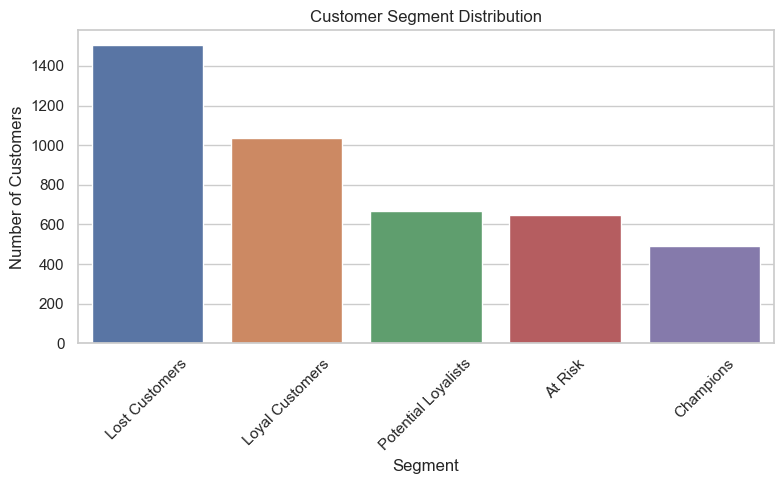

In [ ]:
segment_df = segment_counts.reset_index()
segment_df.columns = ["Segment", "Number of Customers"]

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,5))
sns.barplot(data=segment_df, x="Segment", y="Number of Customers")

plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

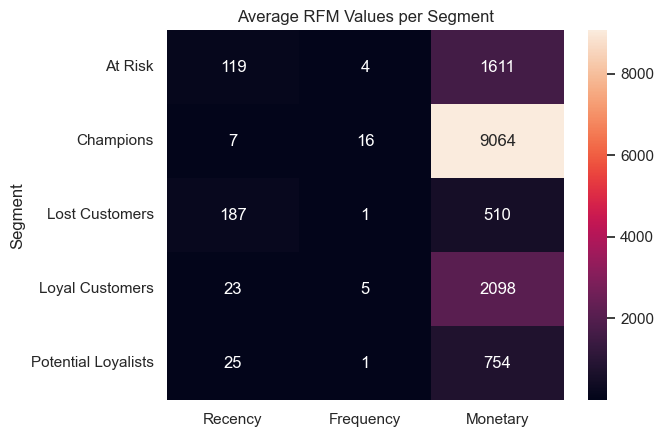

In [11]:
rfm_grouped = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()

plt.figure()
sns.heatmap(rfm_grouped, annot=True, fmt=".0f")
plt.title("Average RFM Values per Segment")
plt.show()

In [12]:
marketing_strategies = {
    "Champions": "Give them special rewards and loyalty discounts to keep them happy.",
    "Loyal Customers": "Encourage them with referral offers and early access to new products.",
    "Potential Loyalists": "Send them personalized suggestions to increase their purchases.",
    "At Risk": "Offer them discounts and reminder emails so they don’t stop buying.",
    "Lost Customers": "Try to bring them back with special offers or comeback coupons."
}
for segment, strategy in marketing_strategies.items():
    print(f"{segment}: {strategy}")

Champions: Give them special rewards and loyalty discounts to keep them happy.
Loyal Customers: Encourage them with referral offers and early access to new products.
Potential Loyalists: Send them personalized suggestions to increase their purchases.
At Risk: Offer them discounts and reminder emails so they don’t stop buying.
Lost Customers: Try to bring them back with special offers or comeback coupons.
